In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

anime_data = pd.read_csv("anime.csv")

anime_data.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [2]:
anime_data.shape

anime_data.info()

anime_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [3]:
anime_data.isnull().sum()

anime_data.duplicated().sum()

np.int64(0)

In [4]:
anime_data = anime_data.dropna()

anime_data.shape

(12017, 7)

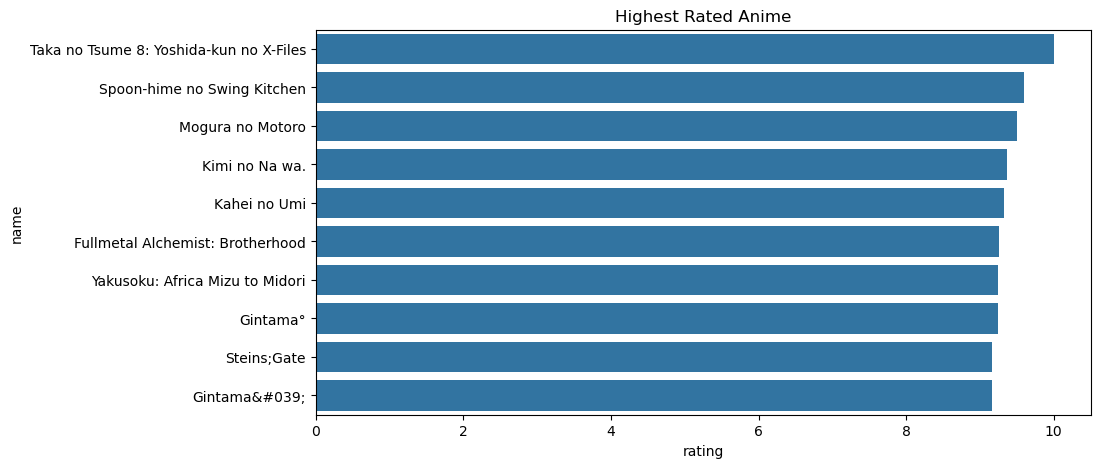

In [5]:
highest_rated = anime_data.sort_values(
    "rating",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=highest_rated,
    x="rating",
    y="name"
)

plt.title("Highest Rated Anime")
plt.show()

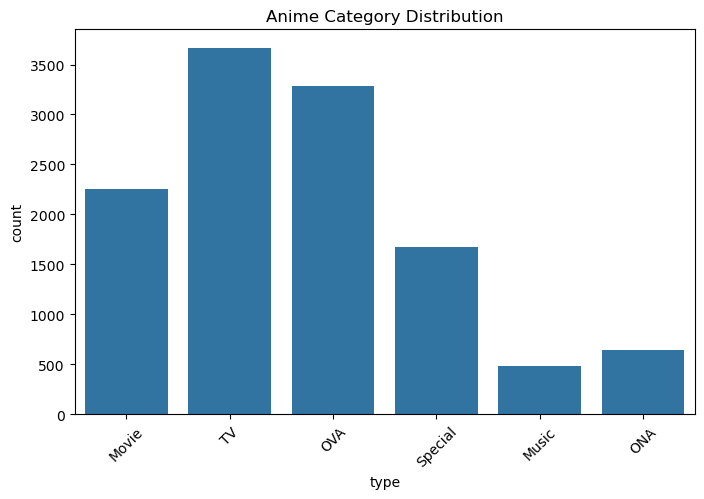

In [6]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=anime_data,
    x="type"
)

plt.xticks(rotation=45)

plt.title("Anime Category Distribution")

plt.show()

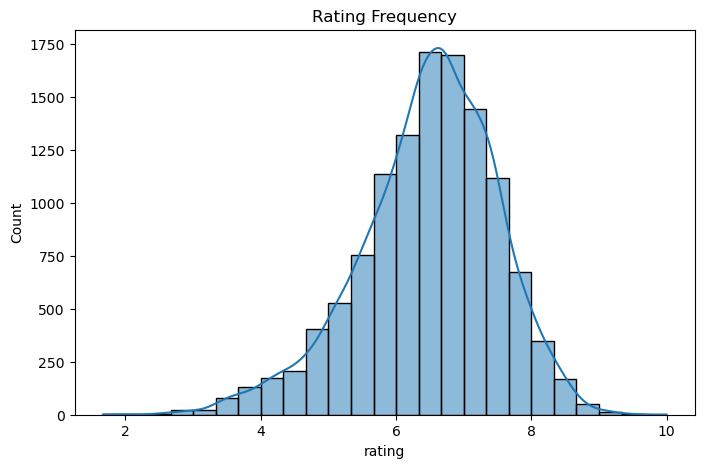

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    anime_data["rating"],
    bins=25,
    kde=True
)

plt.title("Rating Frequency")

plt.show()

In [8]:
recommendation_data = anime_data[
    ["name","genre","rating","members"]
]

recommendation_data.head()

,name,genre,rating,members
0,Kimi no Na wa.,"Drama, Romance, School, Supernatural",9.37,200630
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",9.26,793665
2,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",9.25,114262
3,Steins;Gate,"Sci-Fi, Thriller",9.17,673572
4,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",9.16,151266


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer(
    stop_words="english"
)

genre_matrix = vectorizer.fit_transform(
    recommendation_data["genre"]
)

In [10]:
similarity_matrix = cosine_similarity(
    genre_matrix
)

similarity_matrix.shape

(12017, 12017)

In [11]:
anime_index = pd.Series(
    recommendation_data.index,
    index=recommendation_data["name"]
).drop_duplicates()

In [12]:
def get_recommendations(anime_name):

    anime_position = anime_index[anime_name]

    similarity_scores = list(
        enumerate(
            similarity_matrix[anime_position]
        )
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:6]

    recommended_index = [
        item[0]
        for item in similarity_scores
    ]

    return recommendation_data["name"].iloc[
        recommended_index
    ]

In [13]:
get_recommendations("Naruto")

615                                    Naruto: Shippuuden
841                                                Naruto
1103    Boruto: Naruto the Movie - Naruto ga Hokage ni...
1343                                          Naruto x UT
1472          Naruto: Shippuuden Movie 4 - The Lost Tower
Name: name, dtype: object

In [14]:
import pickle

pickle.dump(
    recommendation_data,
    open("anime_list.pkl","wb")
)

pickle.dump(
    similarity_matrix,
    open("similarity.pkl","wb")
)